In [2]:
import os
import numpy as np
import tensorflow as tf
import checkers
import random
from tqdm import tqdm

# Load models (keep real filenames)
model_dir = "models"
model_files = [f for f in os.listdir(model_dir) if f.endswith(".keras")]
models = {name: tf.keras.models.load_model(os.path.join(model_dir, name)) for name in model_files}

# Add fixed bots
models["RandomBot"] = "random"
models["MinimaxBot"] = "minimax"
model_names = list(models.keys())  # now includes keras models + bots

# Setup results
N = len(models)
results = np.zeros((N, N))

# Play one game between two models or bots
def play_game(model1, model2, first_player=1, verbose=False):
    game = checkers.Checkers()
    player = first_player
    move_count = 0
    while True:
        if move_count > 1000:
            return 0  # draw
        
        leafs = game.minmax(player, RL=True, depth=1)
        if not leafs:
            return -player
        
        features = np.array([leaf[2][:5] for leaf in leafs])

        if player == 1:
            model = model1 if first_player == 1 else model2
        else:
            model = model2 if first_player == 1 else model1

        # Decide move based on type
        if model == "random":
            move = random.choice(leafs)[0]
        elif model == "minimax":
            move = random.choice(game.minmax(player, RL=False))  # classic minmax
        else:
            scores = model.predict(features, verbose=0)
            move = leafs[np.argmax(scores)][0]

        game.PushMove(move)

        end = game.EndGame()
        if end != 0:
            return end
        
        player *= -1
        move_count += 1

# === How many games
games_per_side = 10

# Round robin (only upper triangle)
for i in range(N):
    for j in range(i+1, N):
        p1_wins = 0
        p2_wins = 0
        draws = 0

        for game_idx in tqdm(range(games_per_side), desc=f"{model_names[i]} vs {model_names[j]}", leave=True):
            if game_idx % 2 == 0:
                result = play_game(models[model_names[i]], models[model_names[j]])
            else:
                result = play_game(models[model_names[j]], models[model_names[i]])

            if result == 1:
                p1_wins += 1
            elif result == -1:
                p2_wins += 1
            else:
                draws += 1

        total_games = p1_wins + p2_wins + draws
        p1_score = (p1_wins + 0.5 * draws) / total_games
        p2_score = (p2_wins + 0.5 * draws) / total_games

        results[i, j] = p1_score
        results[j, i] = p2_score

# Save
np.save("round_robin_results.npy", results)
with open("model_names.txt", "w") as f:
    for name in model_names:
        f.write(name + "\n")


RandomBot vs MinimaxBot: 100%|██████████| 10/10 [00:00<00:00, 13.70it/s]


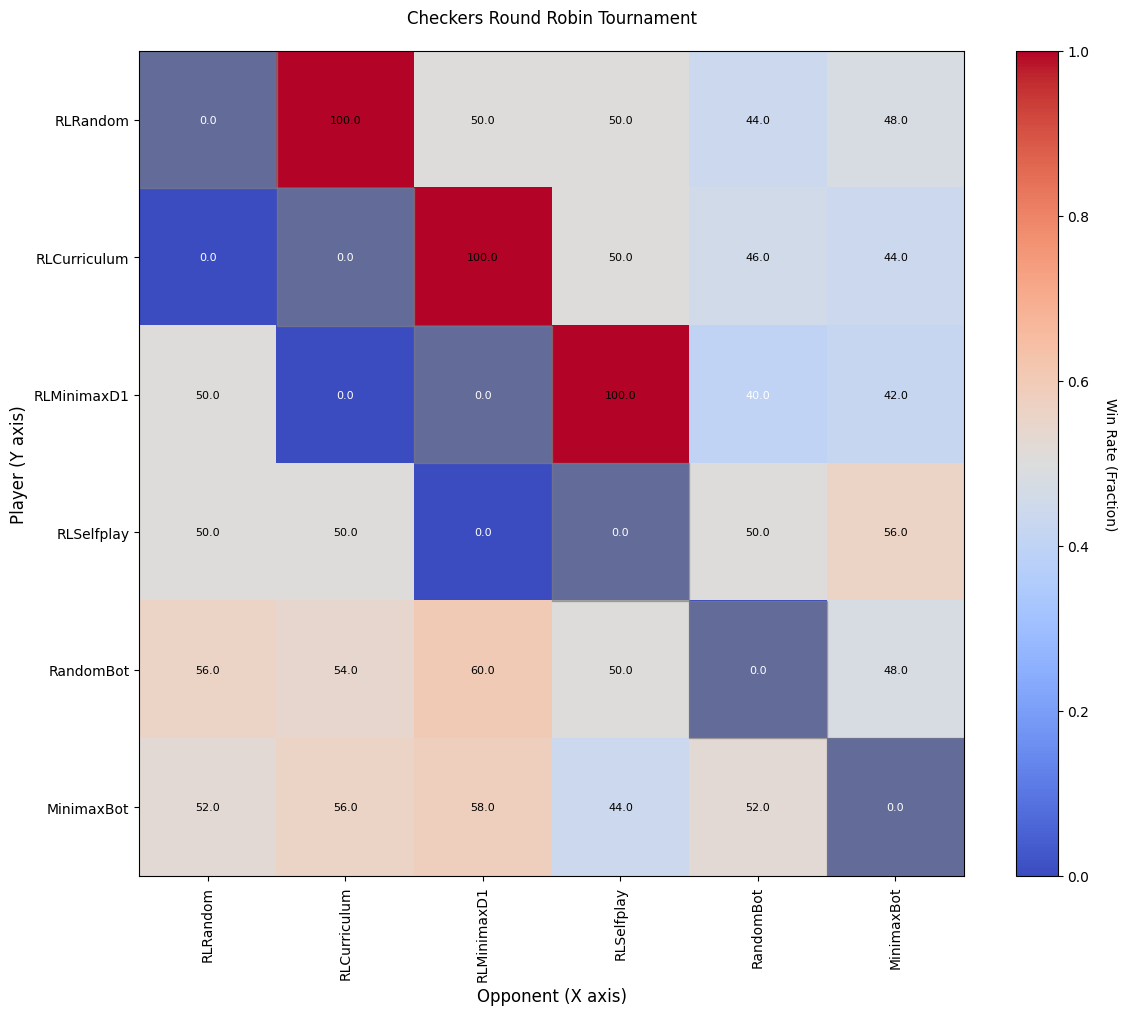

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Load results and model names
results = np.load("round_robin_results.npy")
with open("model_names.txt", "r") as f:
    model_names = [line.strip() for line in f]

# Prettify names
name_mapping = {
    "randomaa.keras": "RLRandom",
    "curriculumaa.keras": "RLCurriculum",
    "minmaxaa.keras": "RLMinimaxD1",
    "itselfaa.keras": "RLSelfplay",
    "RandomBot": "RandomBot",
    "MinimaxBot": "MinimaxBot"
}
model_names = [name_mapping.get(name, name) for name in model_names]

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Use a diverging color map focused on middle values
im = ax.imshow(results, cmap="coolwarm", interpolation="nearest", vmin=0, vmax=1)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Win Rate (Fraction)", rotation=270, labelpad=20)

# Ticks
ax.set_xticks(range(len(model_names)))
ax.set_yticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=90)
ax.set_yticklabels(model_names)

# Add numbers inside squares
for i in range(results.shape[0]):
    for j in range(results.shape[1]):
        if not np.isnan(results[i, j]):
            text = f"{results[i, j]*100:.1f}"  # Show as percentage
            ax.text(j, i, text, ha="center", va="center",
                    color="black" if results[i, j] > 0.4 else "white", fontsize=8)

# Make diagonal cells darker gray
for i in range(len(model_names)):
    ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=True, color="gray", alpha=0.6))

# Labels and title
ax.set_xlabel("Opponent (X axis)", fontsize=12)
ax.set_ylabel("Player (Y axis)", fontsize=12)
ax.set_title("Checkers Round Robin Tournament", pad=20)

ax.grid(False)
plt.tight_layout()
plt.show()
